# LIBRARIES IMPORTATION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
ConfusionMatrixDisplay, classification_report)
import warnings
warnings.filterwarnings('ignore')
# Used ordinal encoding to maintain order

In [2]:
pd.set_option('display.max.column', None)
pd.set_option('display.max.row', None)

# PLOT STYLE

In [3]:
plt.style.use('tableau-colorblind10')

# DATA IMPORTATION 

In [4]:
df = pd.read_csv("StressLevelDataset.csv")
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,3,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,2,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,3,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,2,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,4,3,4,3,1,2,1,5,0,5,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    1100 non-null 

# DATA CLEANING

In [6]:
missing_values = df.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# No Stress → 0
# Eustress (positive stress) → 1
# Distress (negative stress) → 2
df['stress_level'] = df['stress_level'].map({0 : 'No Stress' , 1 : 'Eustress (positive stress)', 
                                             2 : 'Distress (negative stress)'})

In [9]:
num_cols = df.select_dtypes(include = ['int',  'float'])

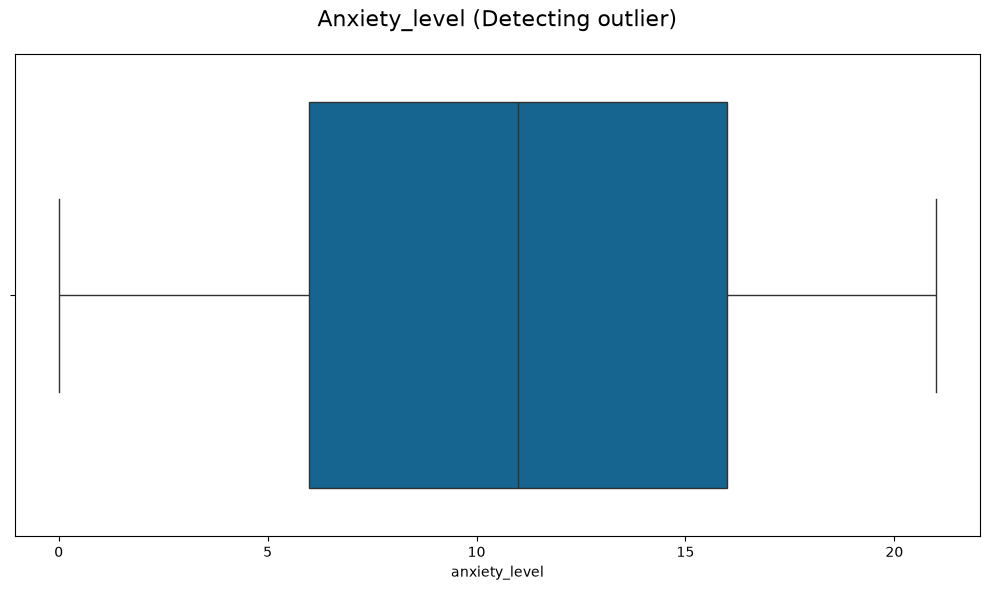

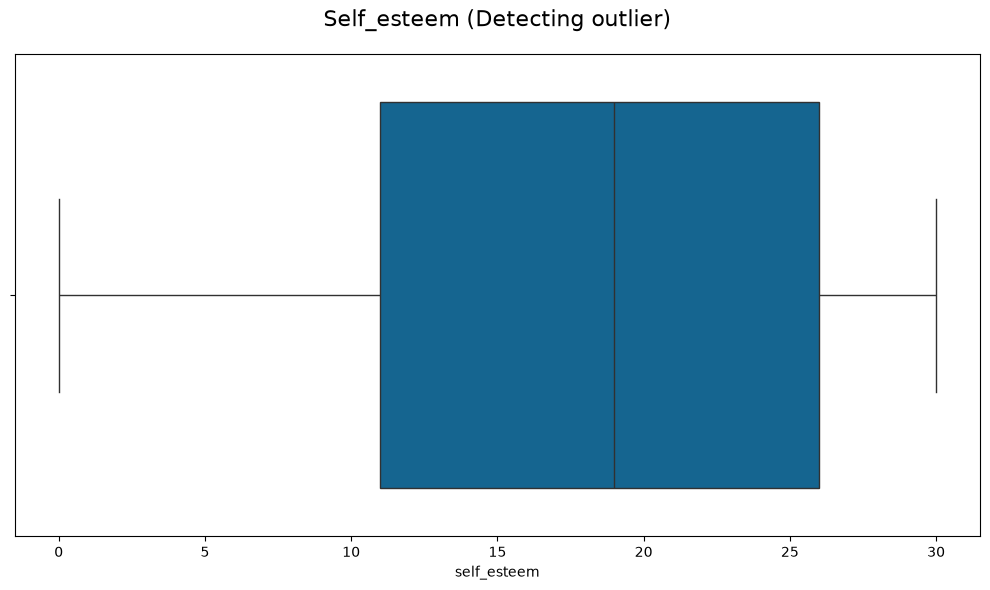

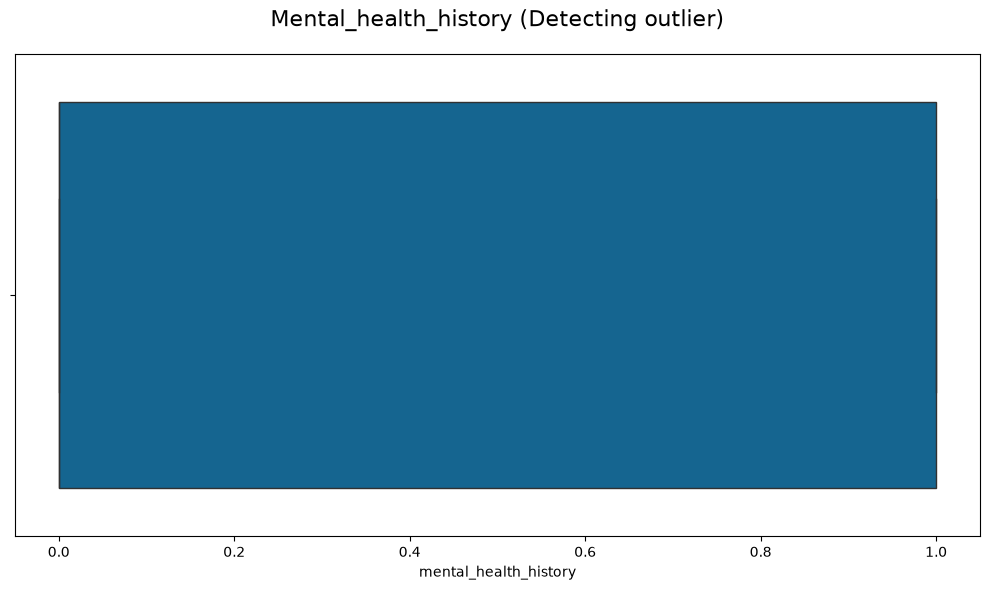

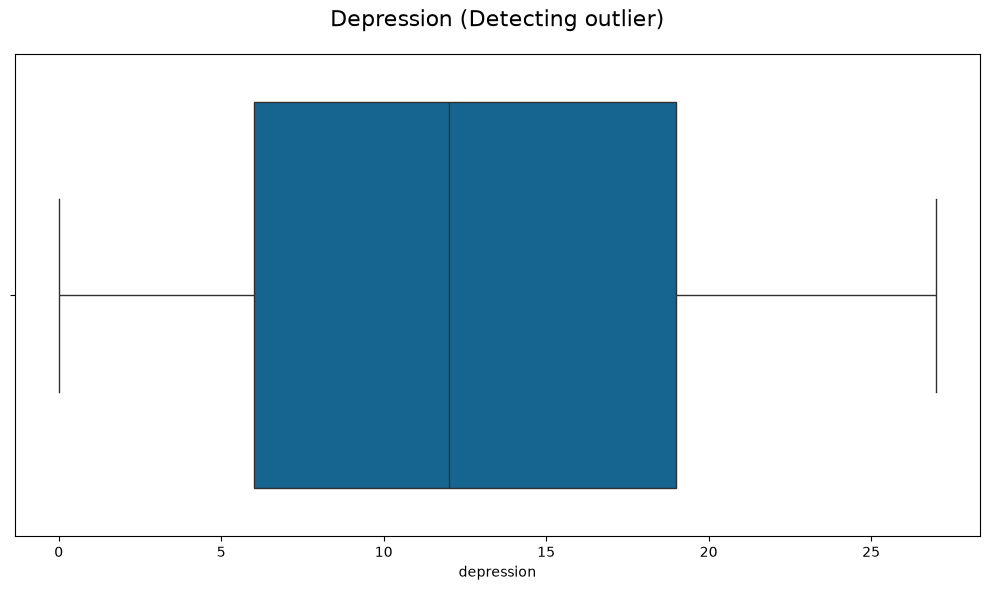

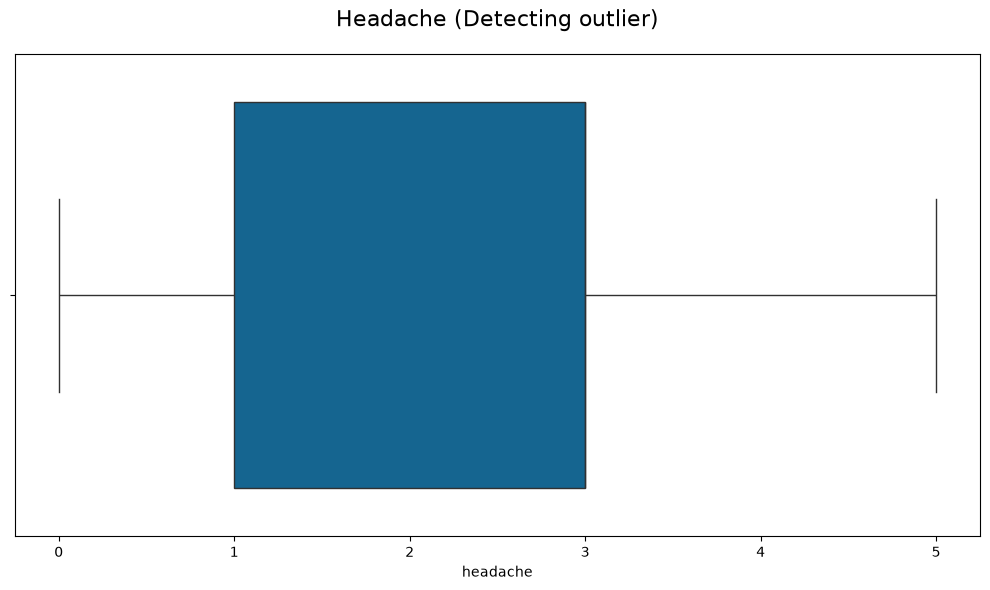

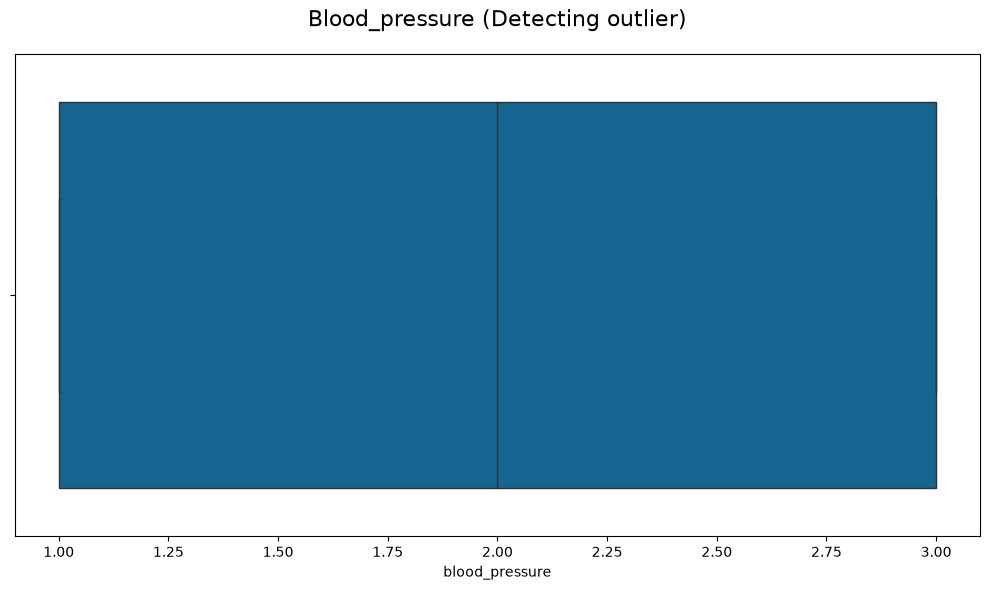

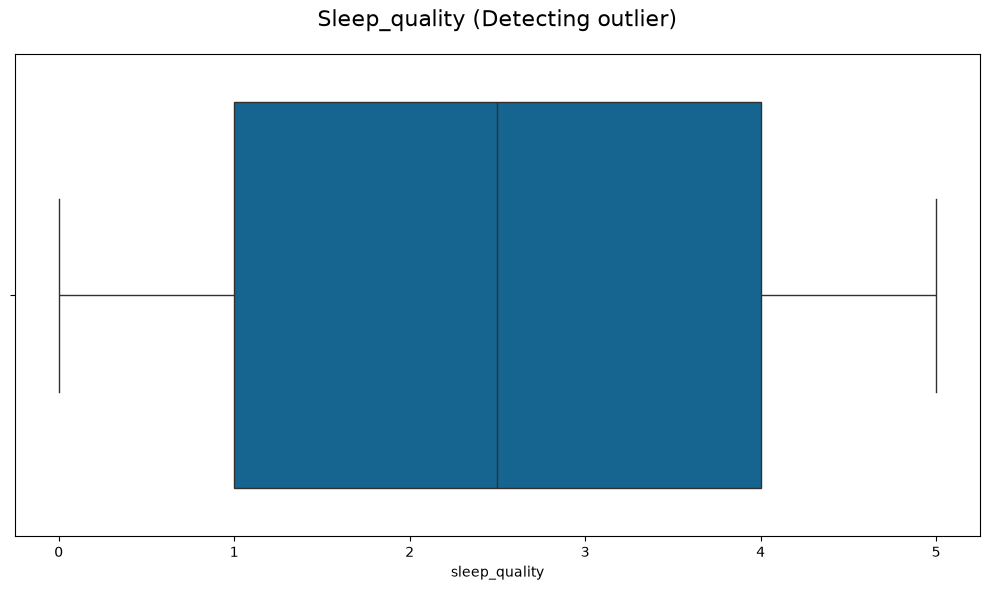

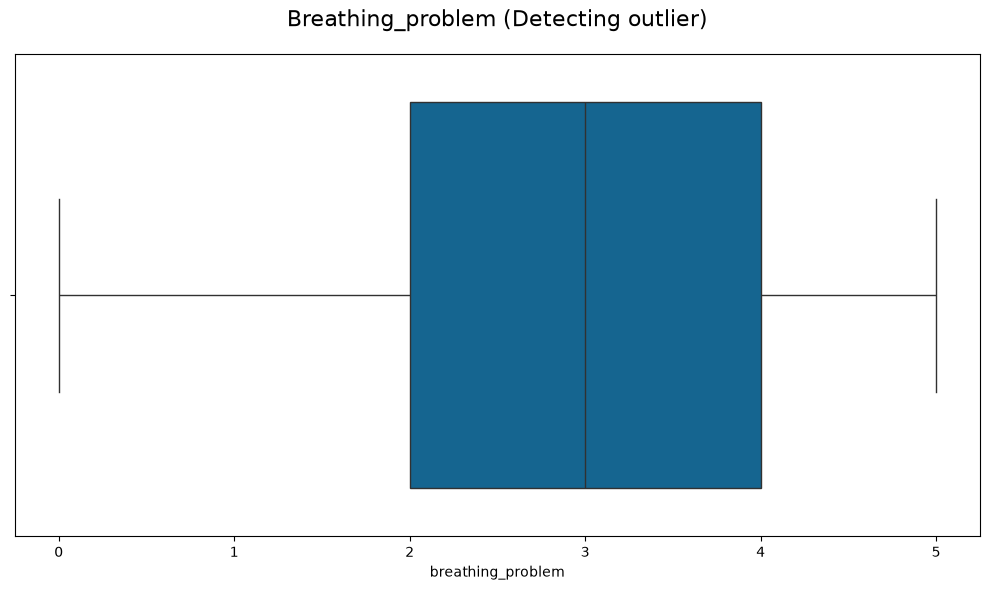

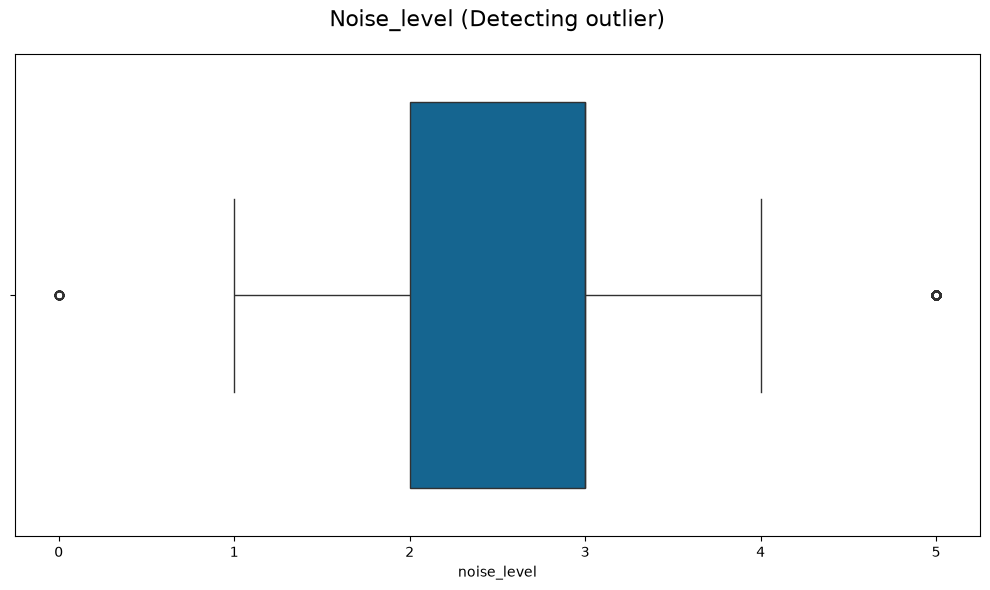

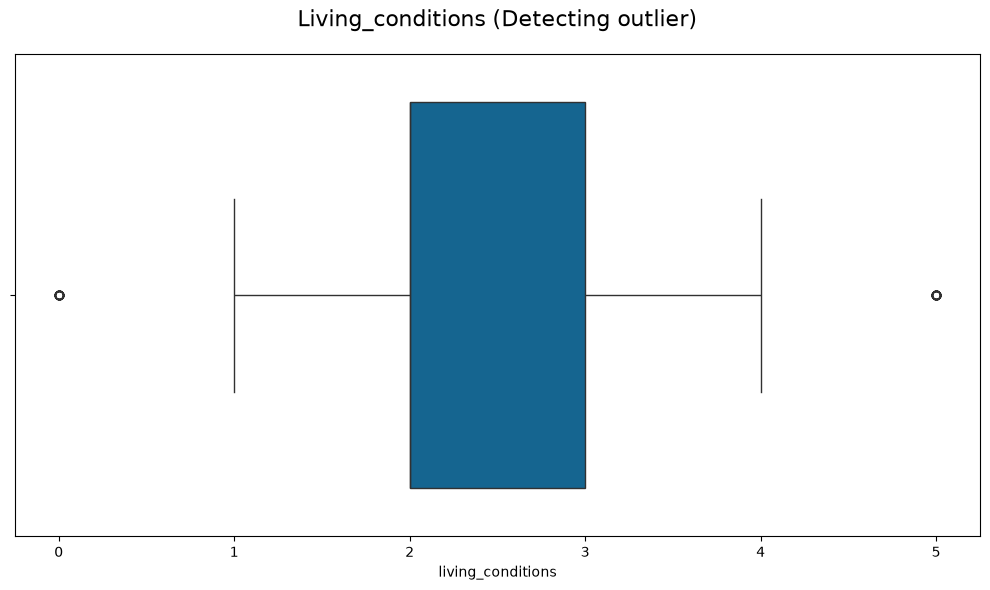

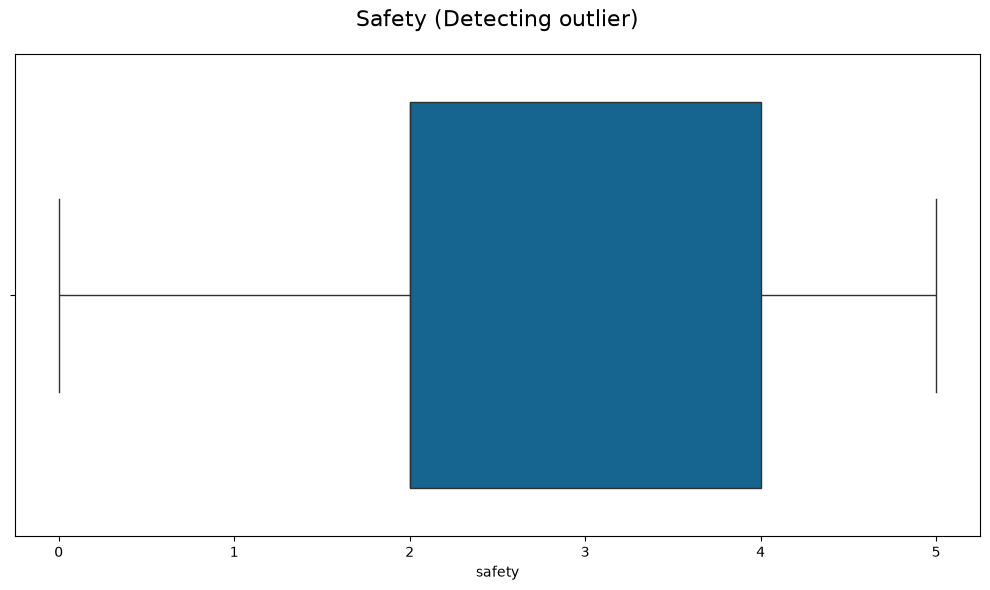

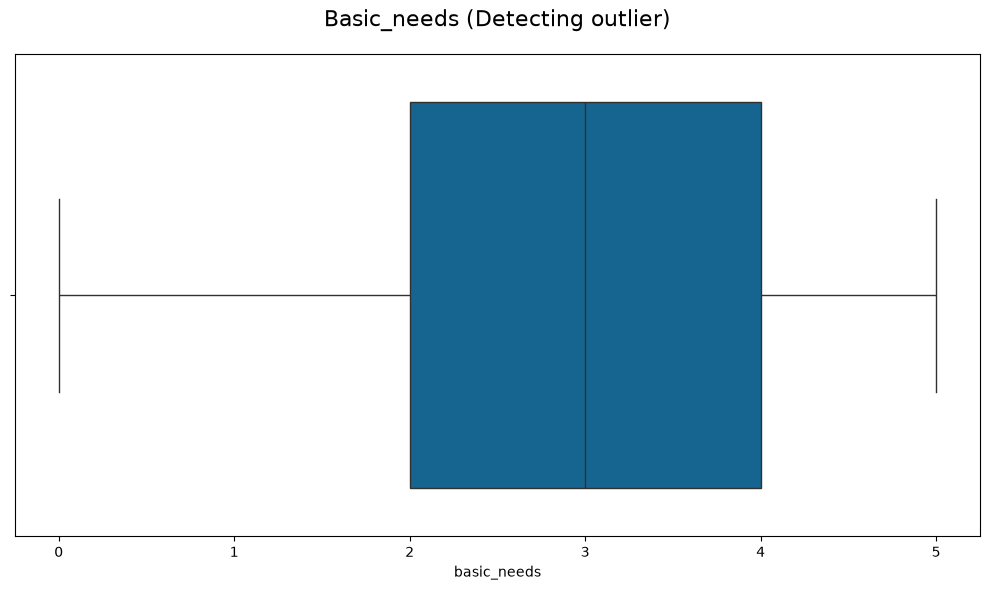

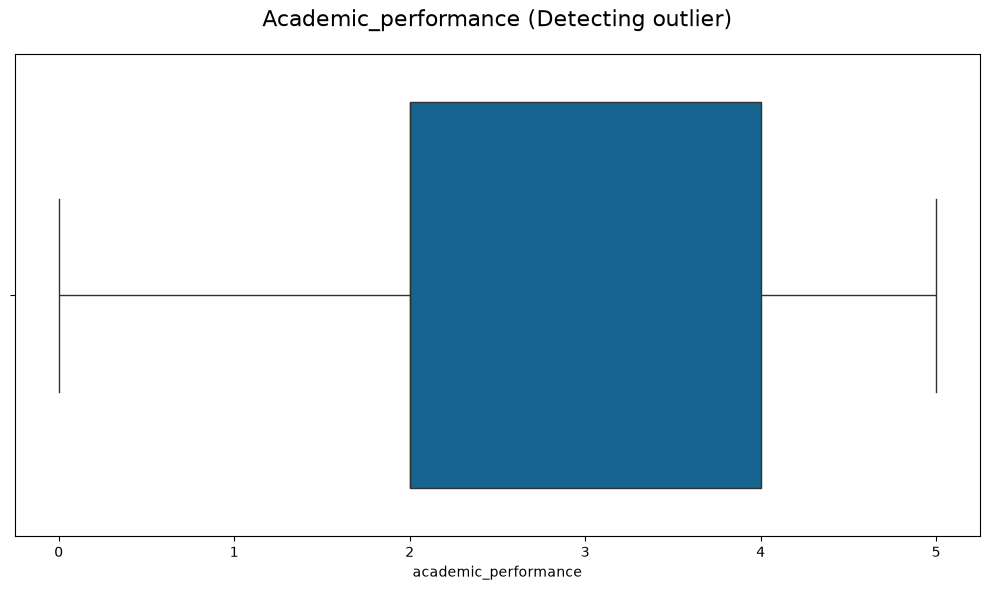

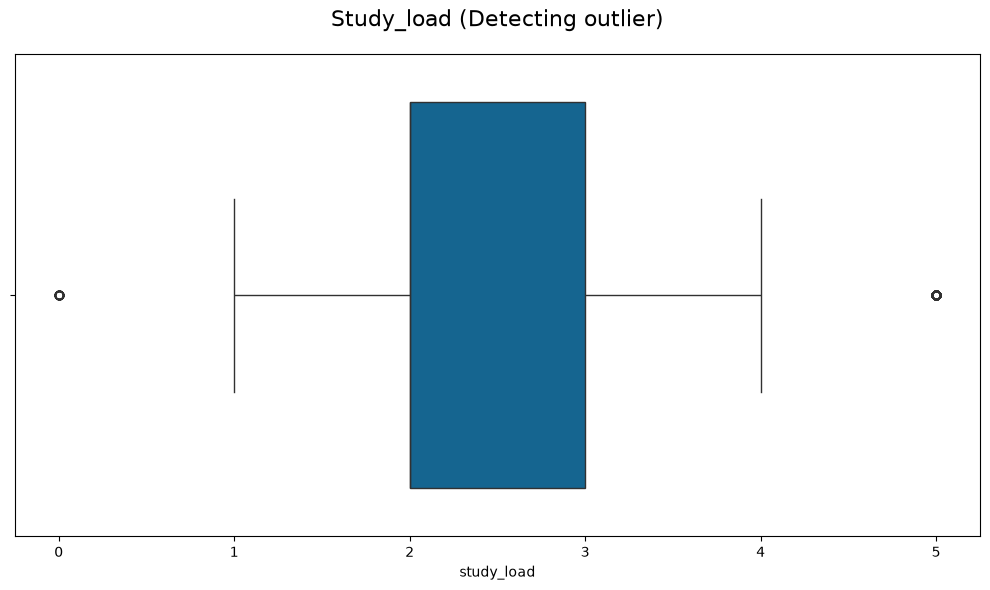

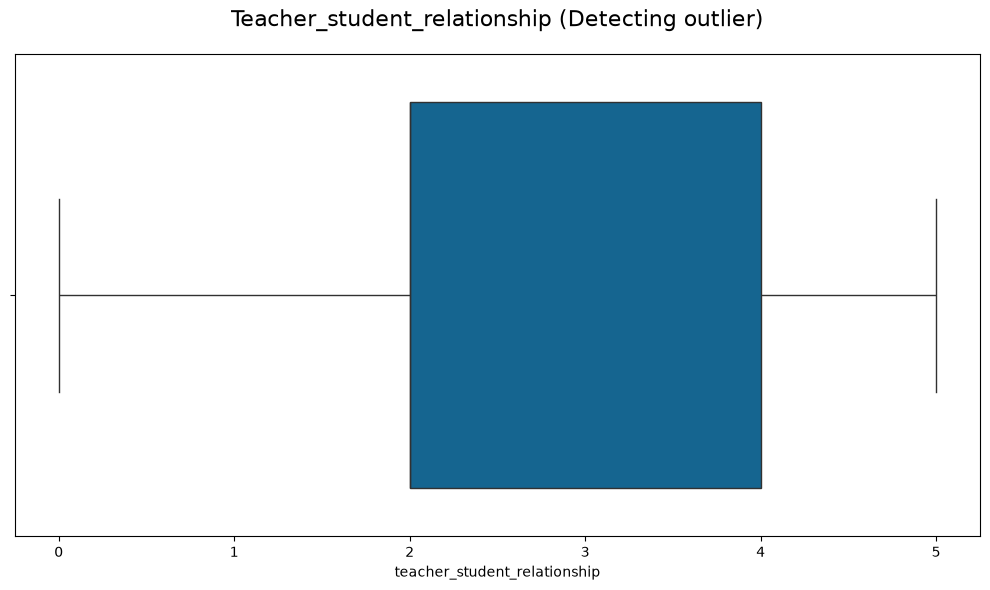

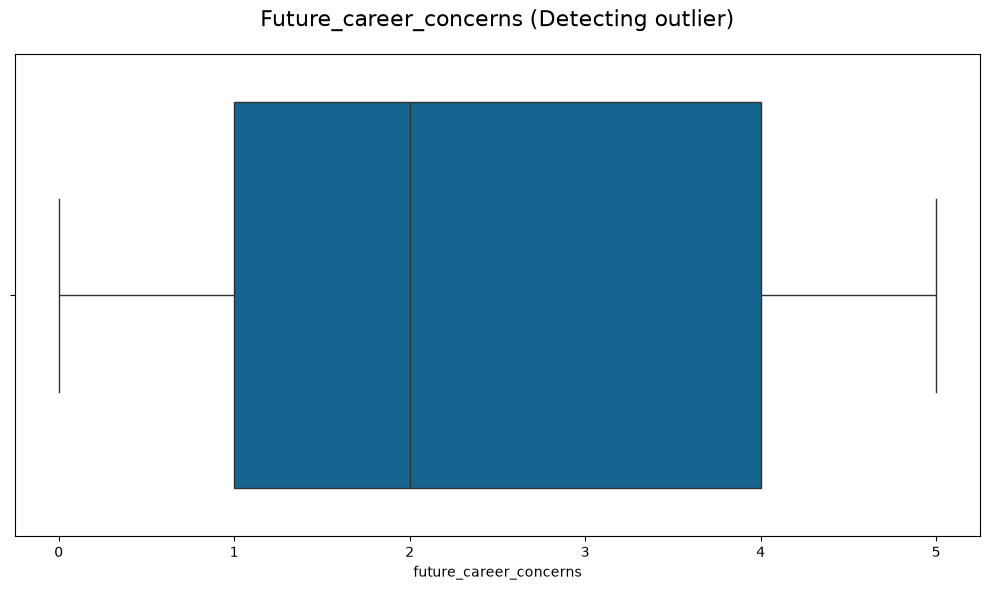

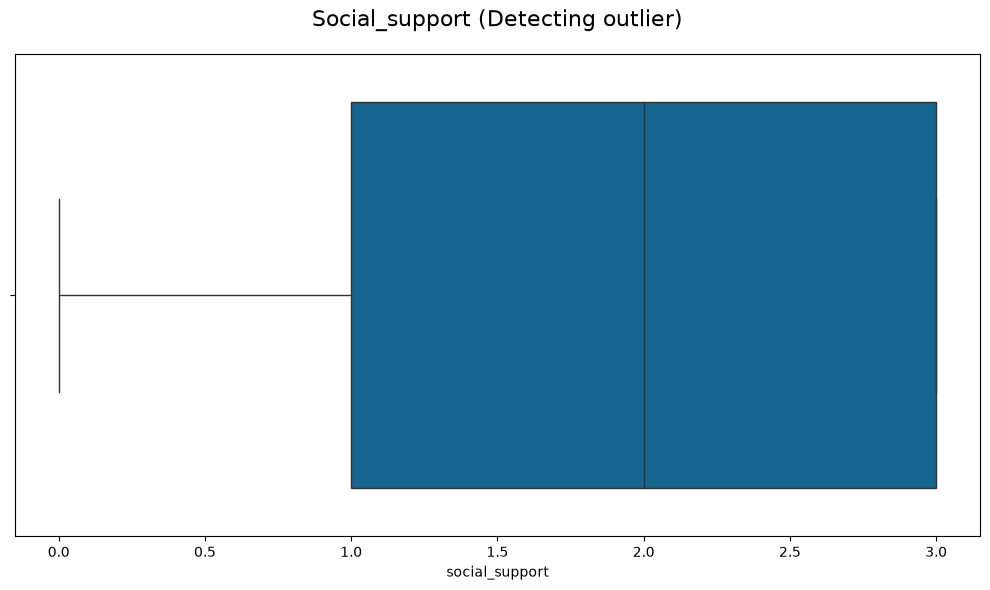

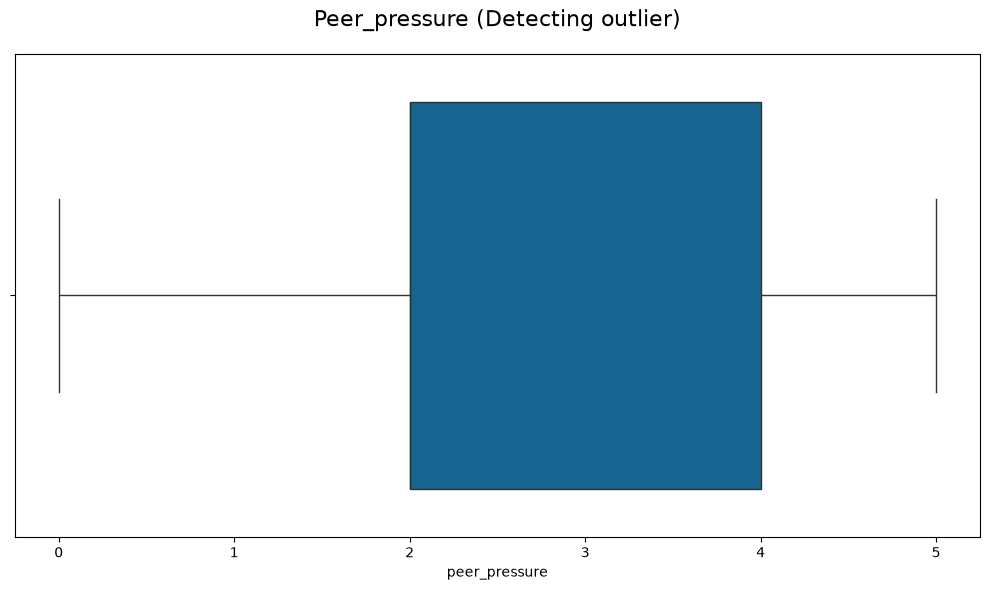

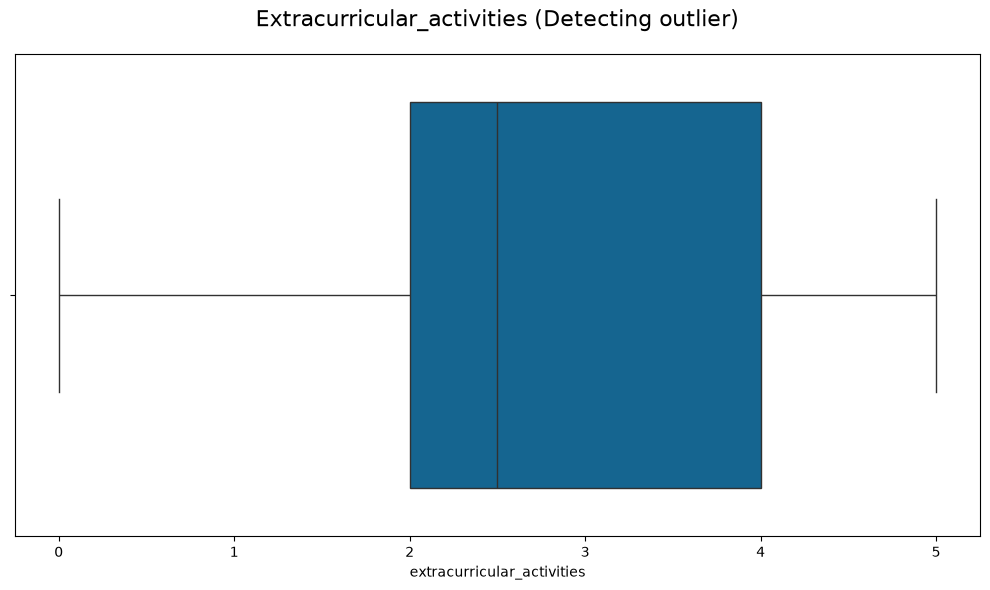

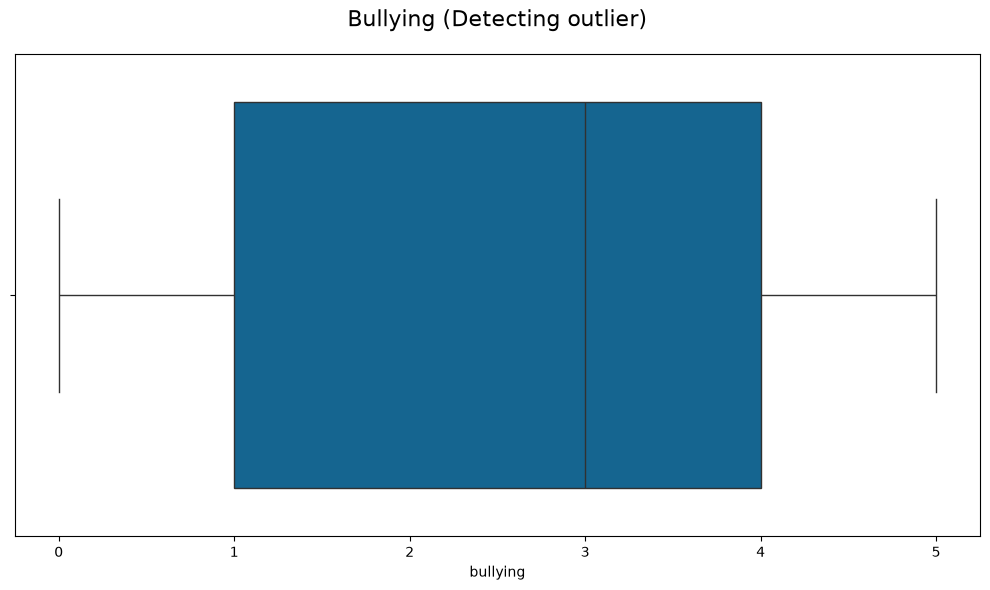

In [10]:
for col in num_cols:
    plt.figure(figsize = (10, 6))
    sns.boxplot(x = df[col])
    plt.title(f'{col.capitalize()} (Detecting outlier)', y = 1.04, fontsize = 16)
    plt.tight_layout()
    plt.show()

In [11]:
# The outlier are few, let remove about 5%
for col in num_cols:
    df[col] = winsorize(df[col], limits = [0.05, 0.05])

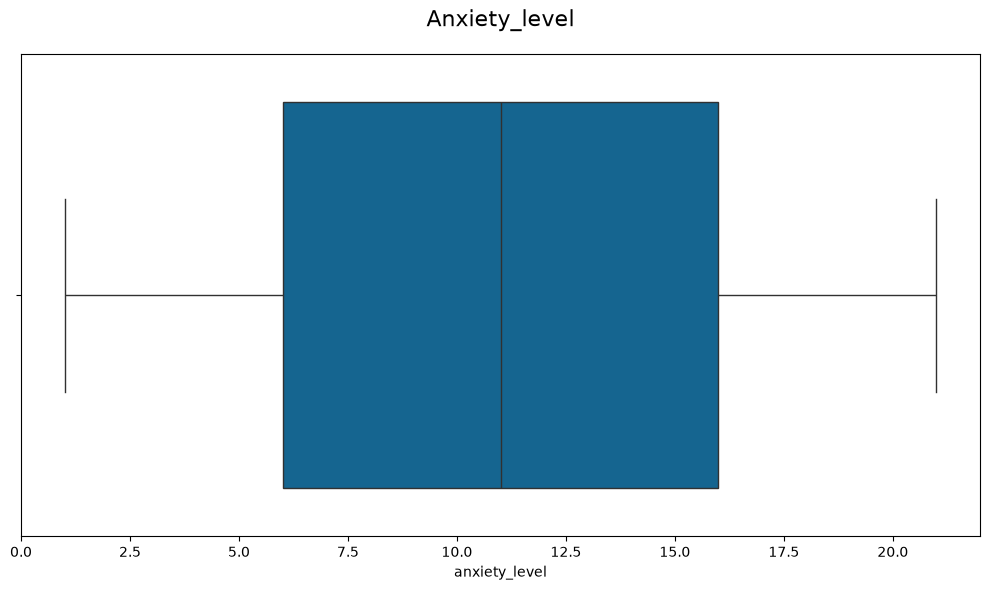

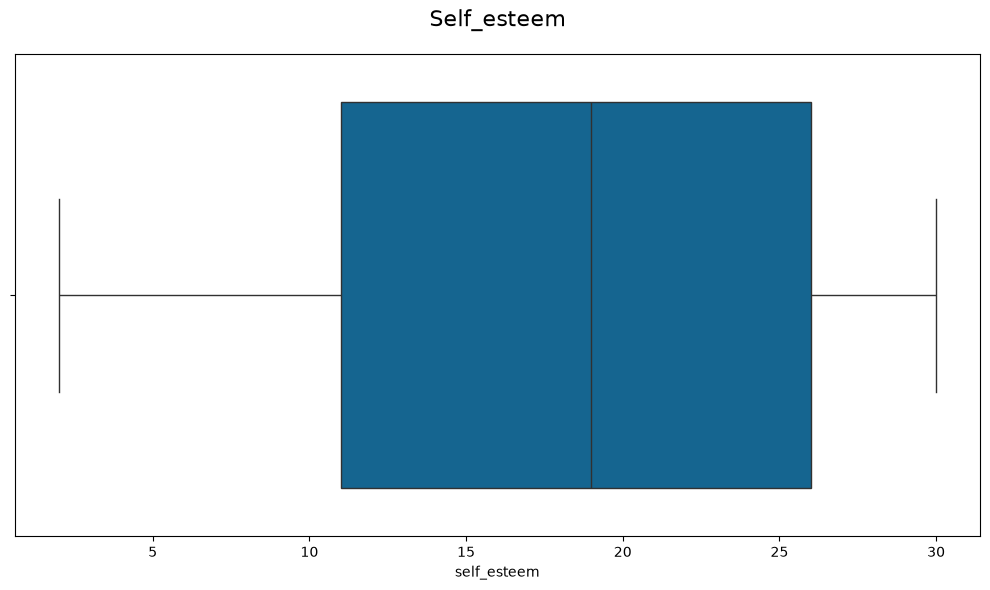

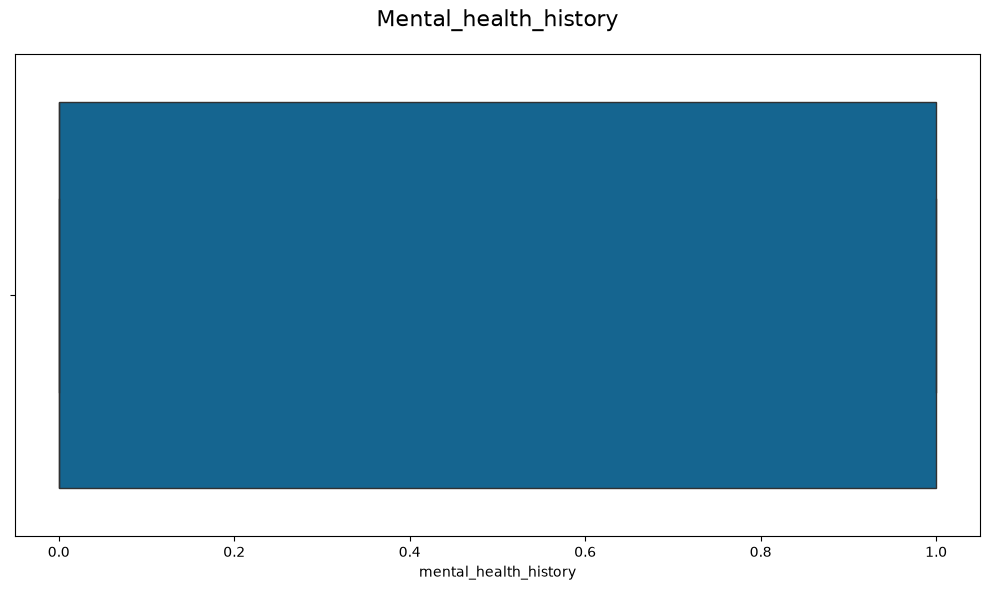

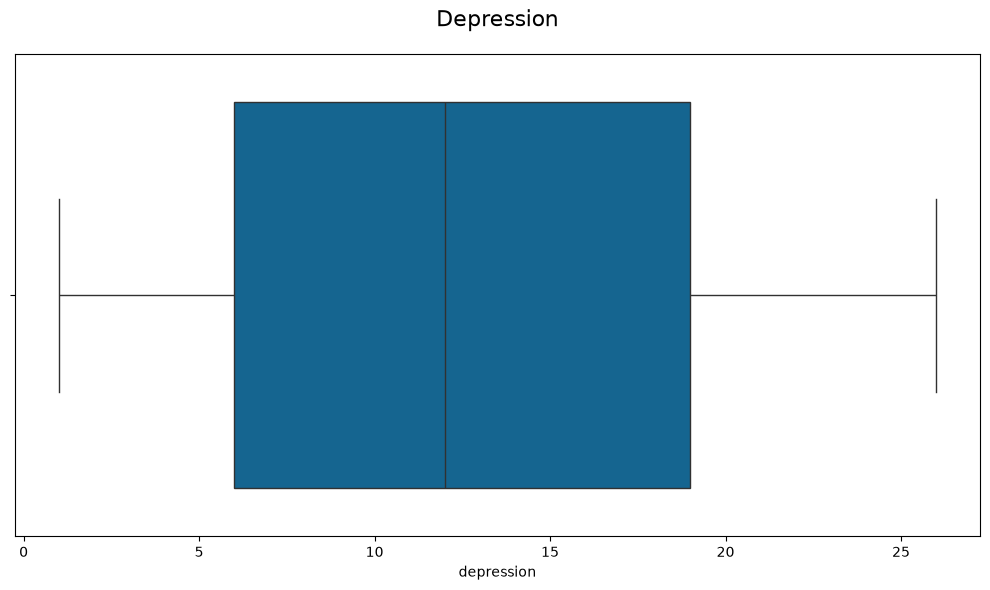

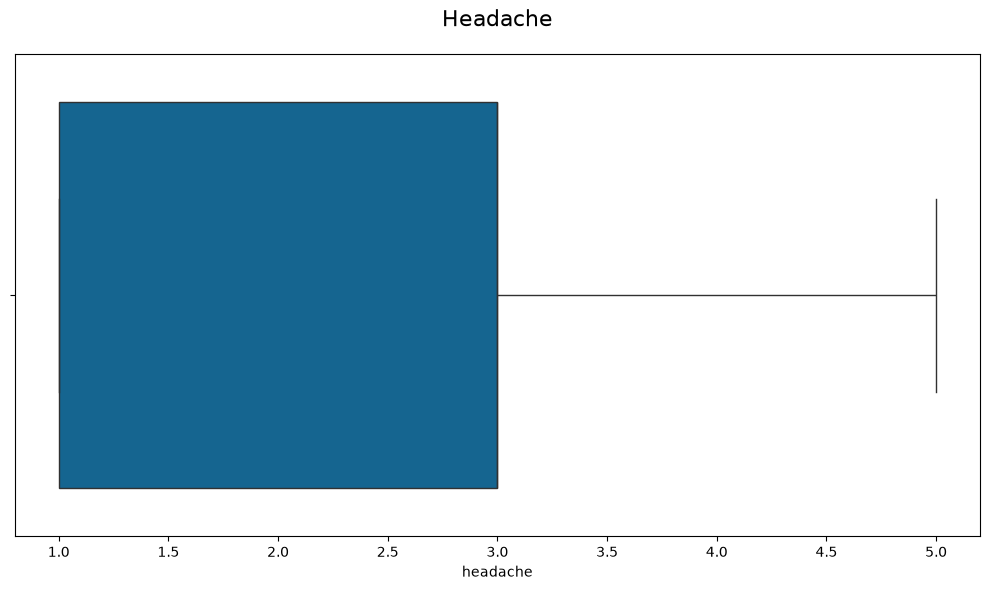

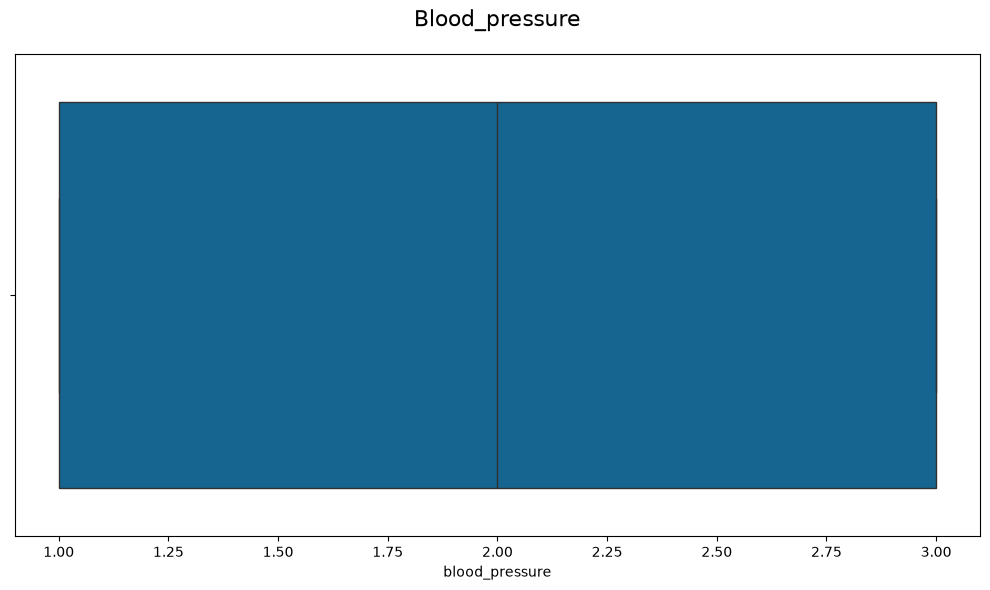

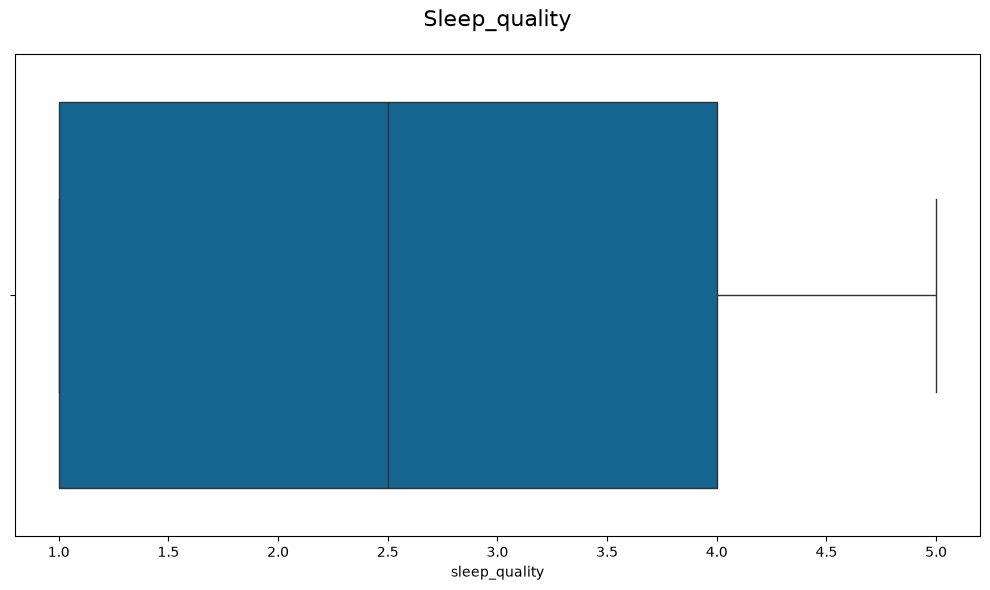

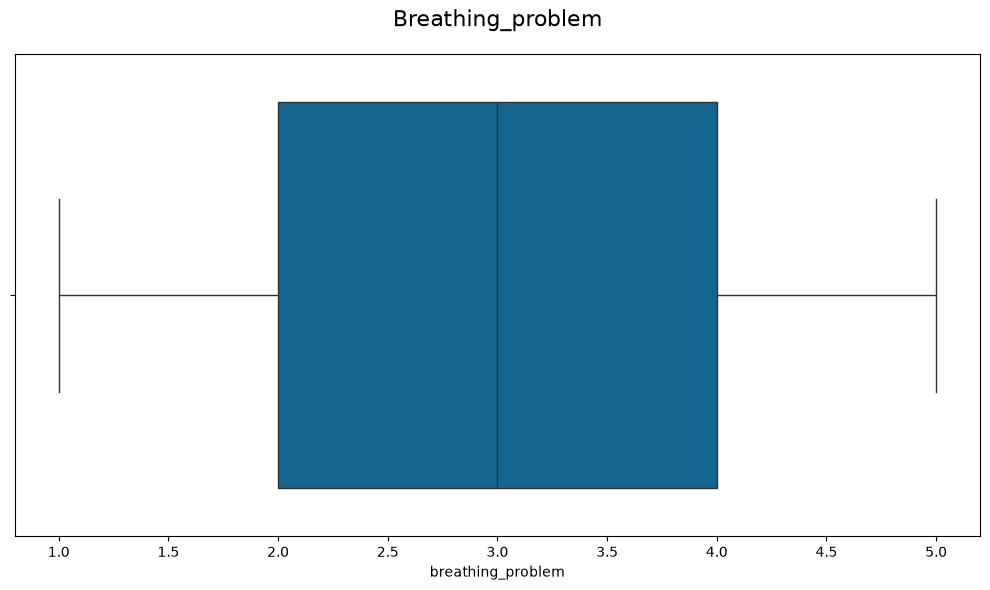

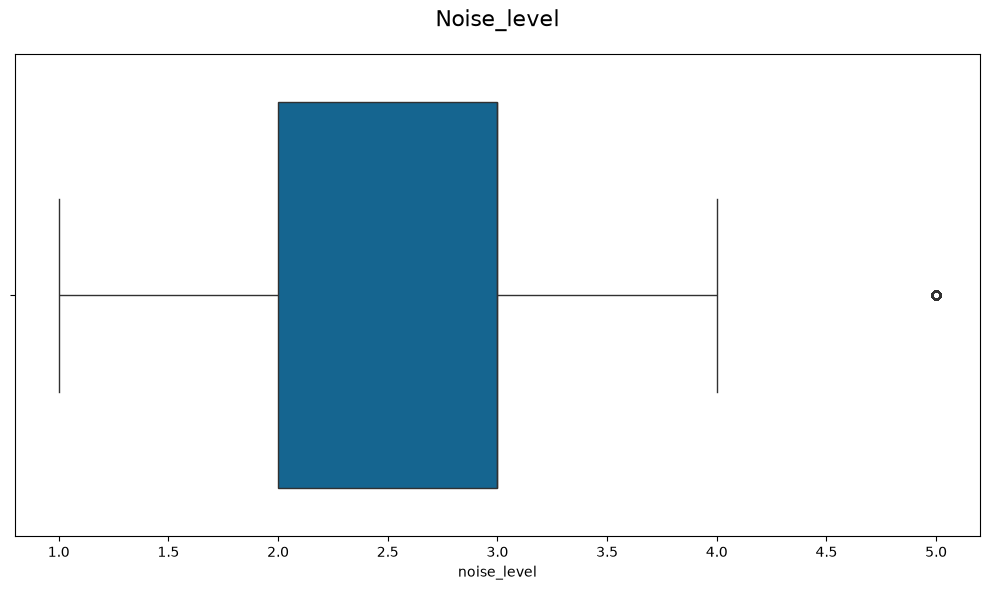

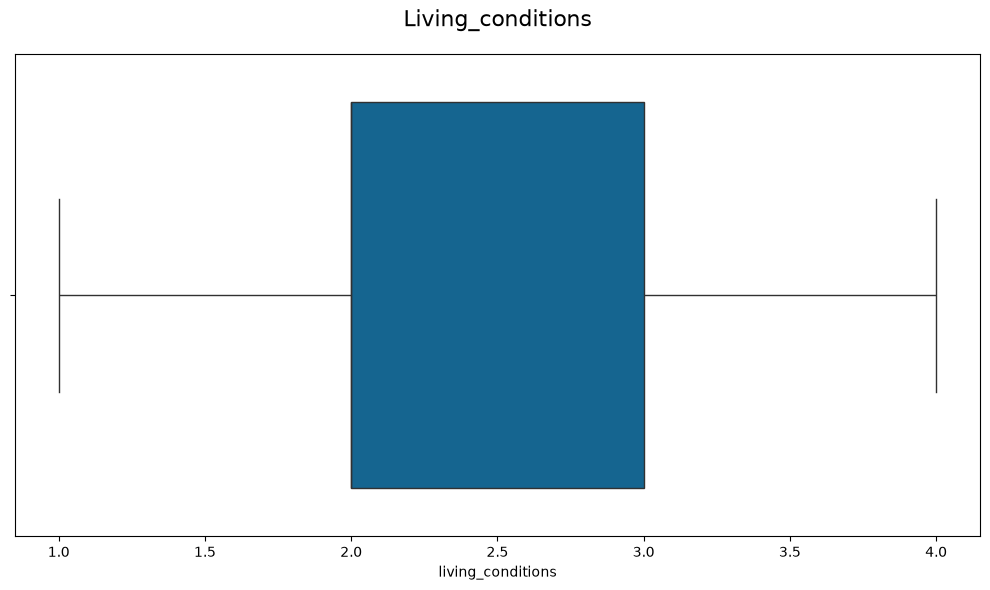

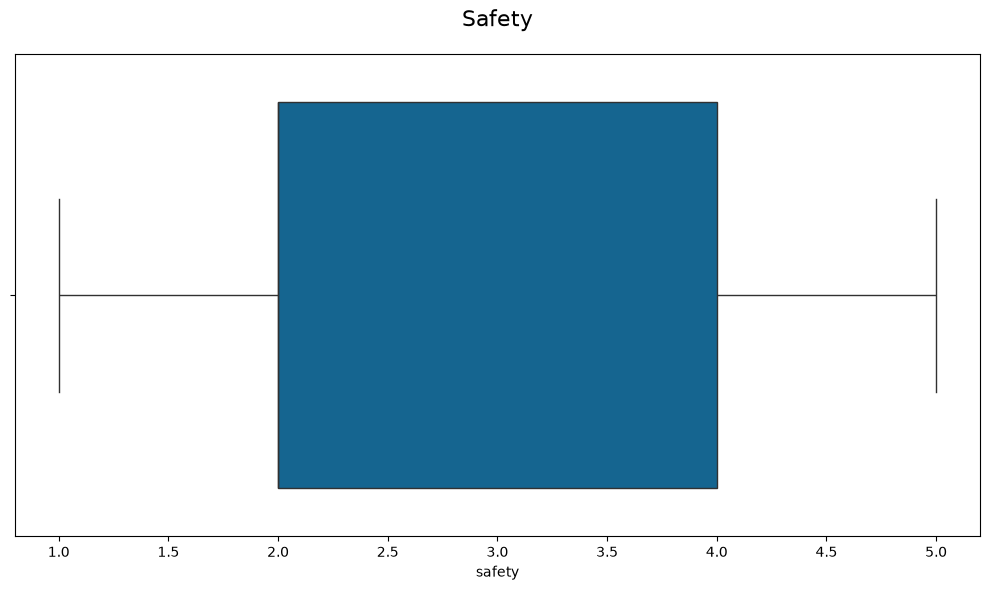

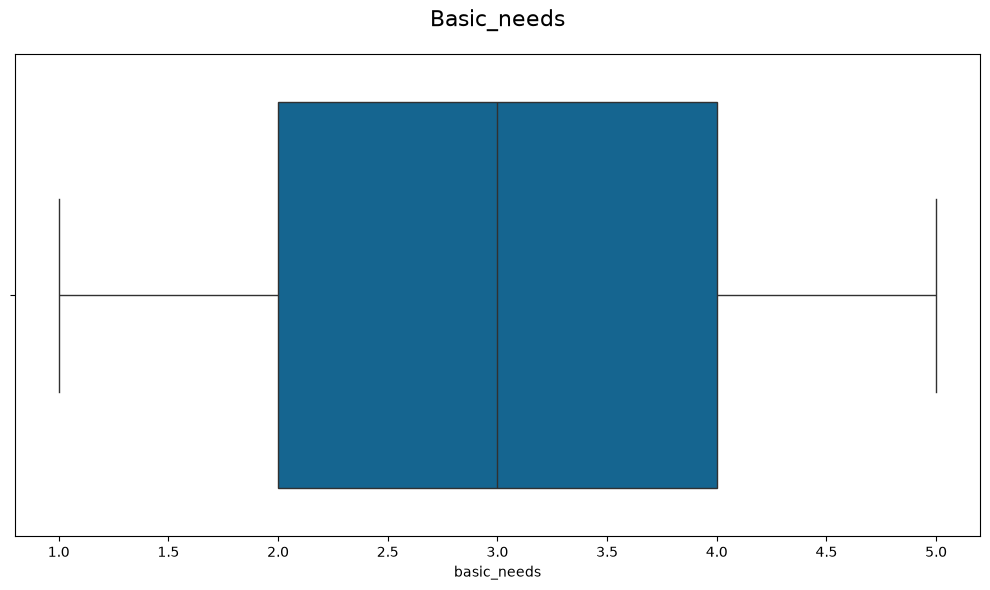

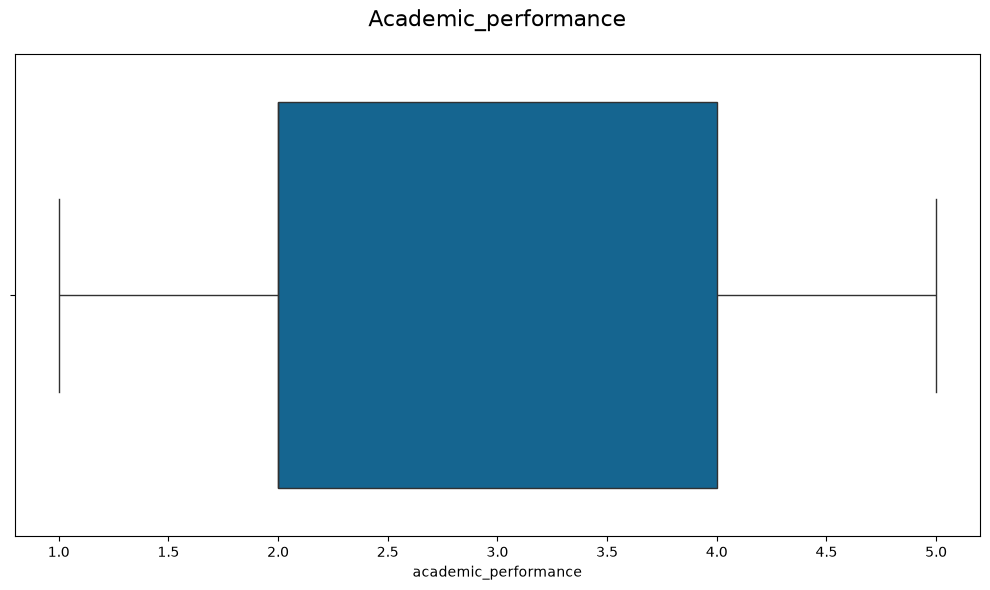

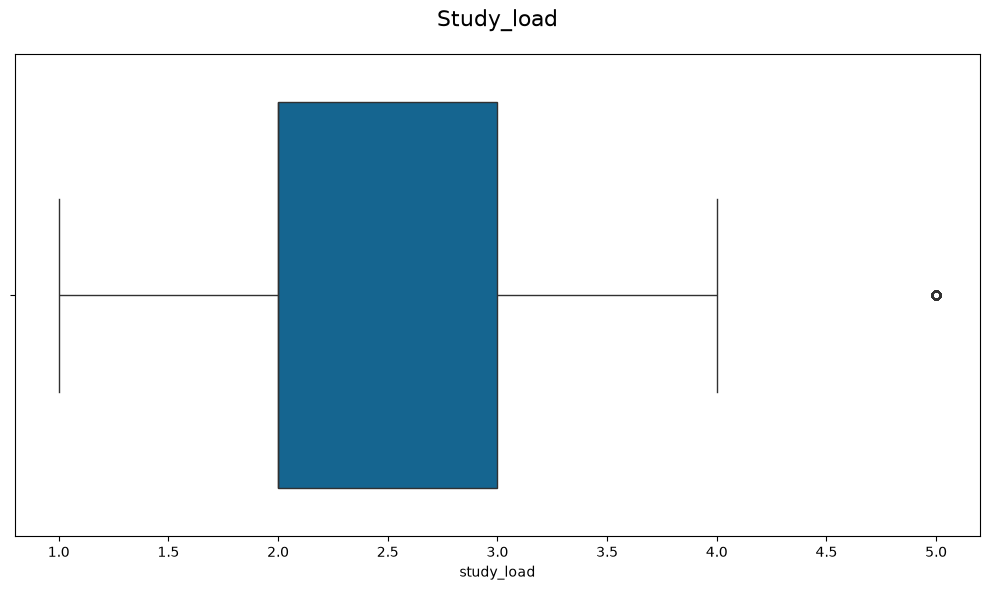

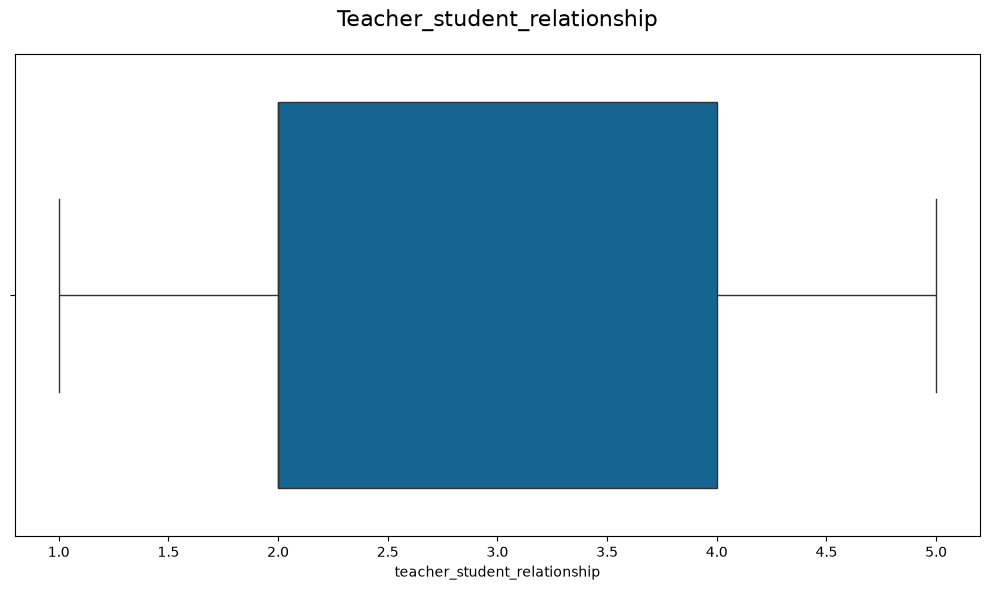

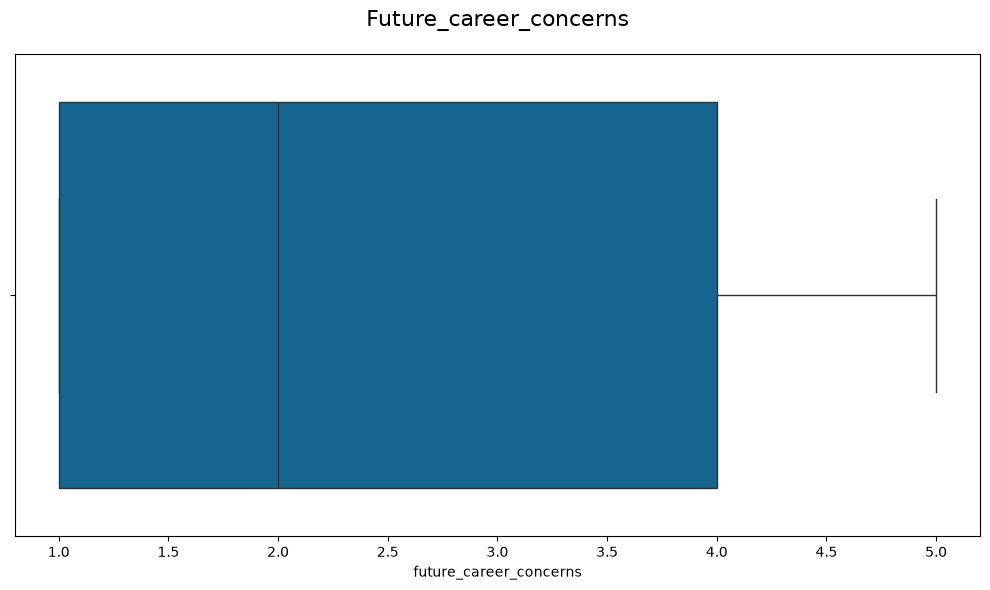

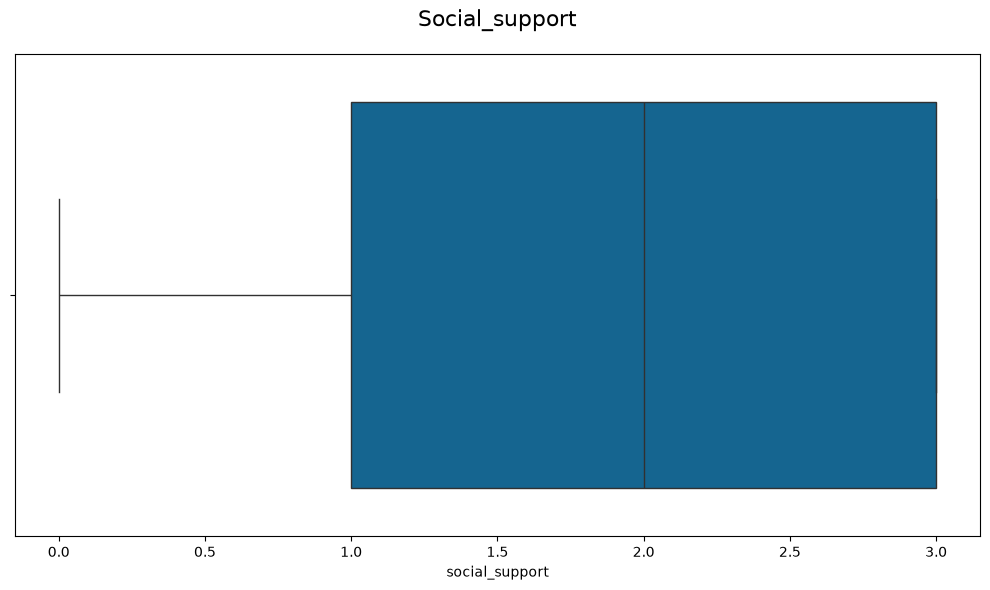

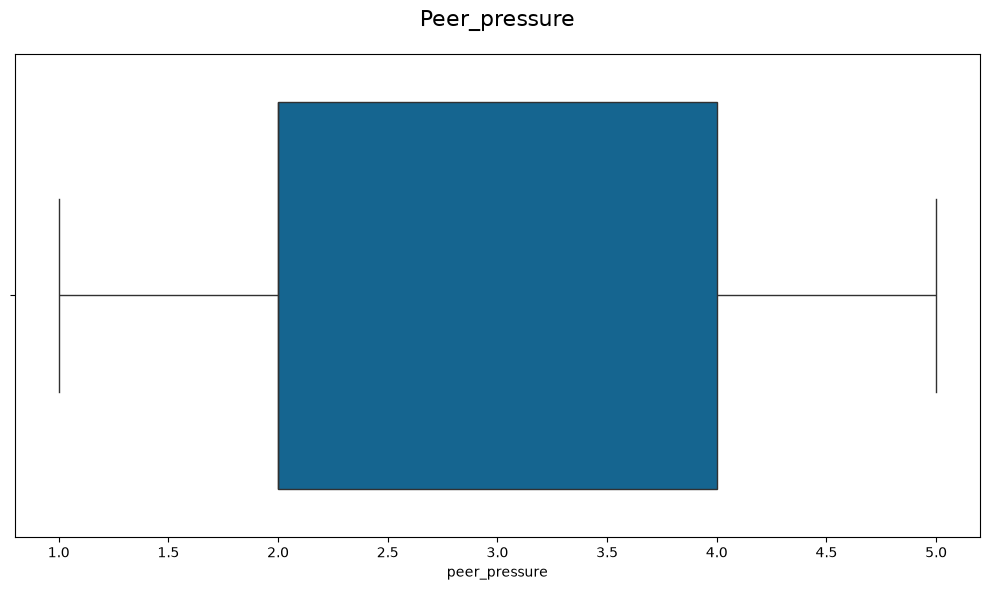

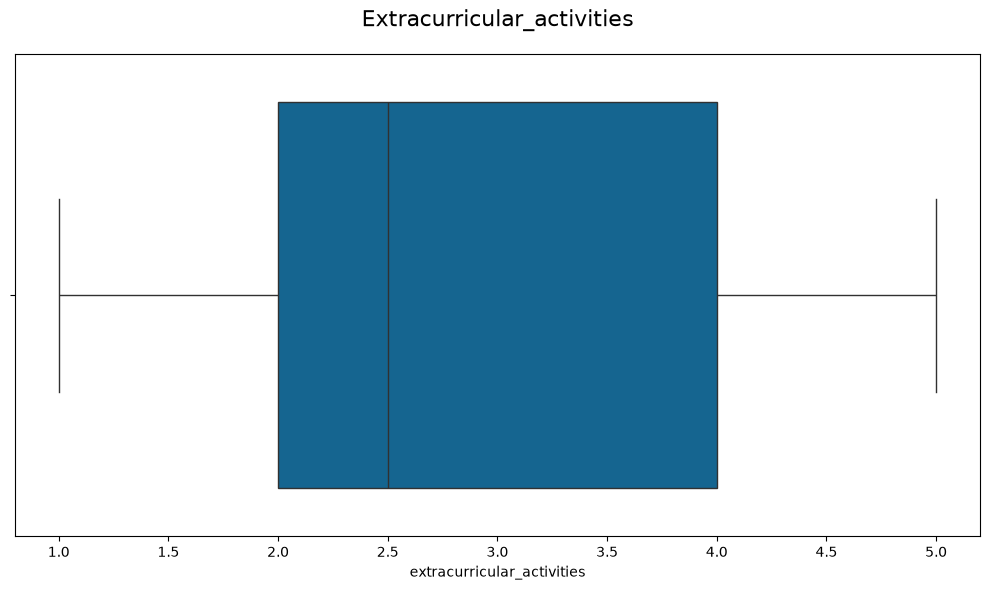

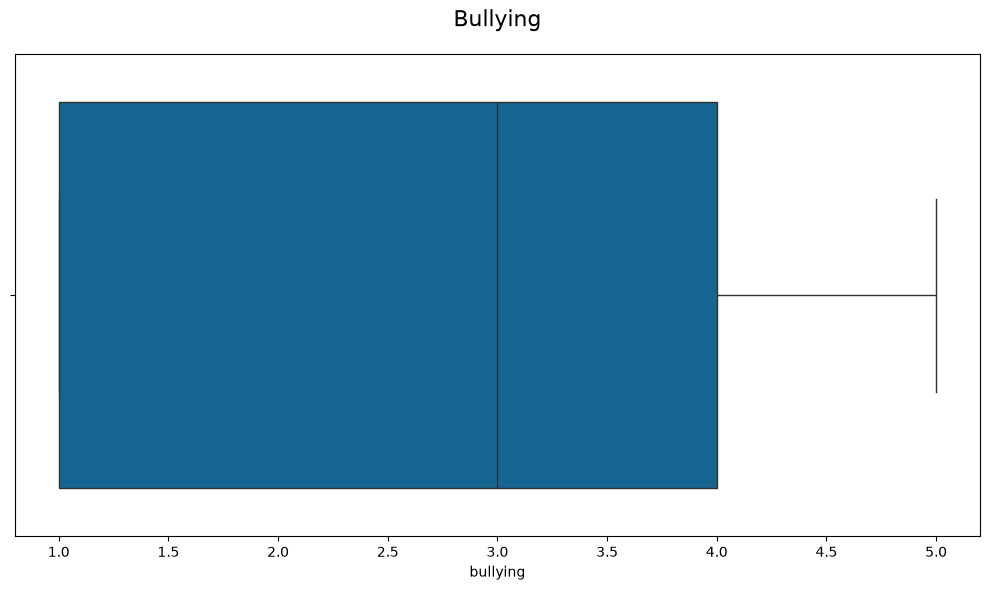

In [12]:
for col in num_cols:
    plt.figure(figsize = (10, 6))
    sns.boxplot(x = df[col])
    plt.title(f'{col.capitalize()}', y = 1.04, fontsize = 16)
    plt.tight_layout()
    plt.show()

In [13]:
df['stress_level'].value_counts()

stress_level
No Stress                     373
Distress (negative stress)    369
Eustress (positive stress)    358
Name: count, dtype: int64

In [14]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.090000,17.846364,0.492727,12.562727,2.537273,2.181818,2.690909,2.792727,2.681818,2.514545,2.767273,2.809091,2.798182,2.655455,2.686364,2.676364,1.881818,2.768182,2.798182,2.652727
std,6.071764,8.815108,0.500175,7.604454,1.366928,0.833575,1.504288,1.335707,1.273598,1.013452,1.357224,1.374375,1.372814,1.259872,1.323407,1.490273,1.047826,1.371053,1.366836,1.480643
min,1.000000,2.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000
max,21.000000,30.000000,1.000000,26.000000,5.000000,3.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000


# DATA PREPROCESSING

In [15]:
ss = StandardScaler()
for col in num_cols:
        df[col] = ss.fit_transform(df[[col]])

In [16]:
encoder = OrdinalEncoder()
df['stress_level'] = encoder.fit_transform(df[['stress_level']])

In [17]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1100.000000
mean,1.776357e-17,-1.453383e-16,1.098112e-16,2.583792e-17,1.081963e-16,2.293115e-16,-9.689219e-18,-1.211152e-16,1.130409e-16,-6.419108e-17,1.259598e-16,3.391227e-17,-1.287859e-16,1.259598e-16,-1.437234e-16,7.266914e-17,1.291896e-17,8.558810e-17,-1.049665e-16,-7.751375e-17,1.003636
std,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,0.821673
min,-1.662546e+00,-1.798455e+00,-9.855588e-01,-1.521212e+00,-1.125130e+00,-1.418416e+00,-1.124570e+00,-1.342766e+00,-1.321125e+00,-1.495121e+00,-1.302715e+00,-1.316899e+00,-1.310447e+00,-1.314584e+00,-1.274839e+00,-1.125381e+00,-1.796742e+00,-1.290239e+00,-1.316178e+00,-1.116730e+00,0.000000
25%,-8.386879e-01,-7.770158e-01,-9.855588e-01,-8.634035e-01,-1.125130e+00,-1.418416e+00,-1.124570e+00,-5.937586e-01,-5.355913e-01,-5.079464e-01,-5.655820e-01,-5.889650e-01,-5.816846e-01,-5.204916e-01,-5.188697e-01,-1.125381e+00,-8.419517e-01,-5.605407e-01,-5.842288e-01,-1.116730e+00,0.000000
50%,-1.482945e-02,1.309299e-01,-9.855588e-01,-7.403335e-02,3.386703e-01,-2.182179e-01,-1.269676e-01,1.552488e-01,2.499426e-01,-5.079464e-01,-5.655820e-01,1.389693e-01,-5.816846e-01,-5.204916e-01,-5.188697e-01,-4.540585e-01,1.128389e-01,-5.605407e-01,-2.182540e-01,2.346485e-01,1.000000
75%,8.090290e-01,9.253823e-01,1.014653e+00,8.468985e-01,3.386703e-01,9.819805e-01,8.706351e-01,9.042563e-01,2.499426e-01,4.792286e-01,9.086839e-01,8.669036e-01,8.758394e-01,2.736010e-01,9.930685e-01,8.885876e-01,1.067629e+00,8.988552e-01,8.796702e-01,9.103380e-01,2.000000
max,1.632887e+00,1.379355e+00,1.014653e+00,1.767830e+00,1.802471e+00,9.819805e-01,1.535704e+00,1.653264e+00,1.821011e+00,1.466404e+00,1.645817e+00,1.594838e+00,1.604601e+00,1.861786e+00,1.749038e+00,1.559911e+00,1.067629e+00,1.628553e+00,1.611620e+00,1.586027e+00,2.000000


# DATA SPLITTING AND FEATURE SELECTION

In [18]:
X = df.drop(['stress_level'], axis = 1)
y = df['stress_level'].astype(int)

In [19]:
y.value_counts()

stress_level
2    373
0    369
1    358
Name: count, dtype: int64

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(880, 20) (220, 20) (880,) (220,)


In [21]:
X_train.head(2)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
163,-0.014829,-0.323043,-0.985559,-0.337157,-0.39323,-1.418416,0.205567,-0.593759,0.249943,0.479229,0.171551,-0.588965,-0.581685,-0.520492,0.237099,-0.454058,0.112839,-0.560541,-0.584229,0.234649
57,-0.509145,1.152369,-0.985559,-0.994965,-1.12513,-0.218218,1.535704,-0.593759,-1.321125,0.479229,0.908684,0.866904,1.604601,-1.314584,1.749038,-1.125381,1.067629,-0.560541,-1.316178,-1.116730


In [22]:
dt = DecisionTreeClassifier(random_state = 42)

selector = SelectFromModel(estimator = dt, threshold = 'median')
selector.fit(X, y)

# Get the mask of selected features
selected_features = X.columns[selector.get_support()]
print(selected_features)

Index(['anxiety_level', 'self_esteem', 'depression', 'blood_pressure',
       'sleep_quality', 'breathing_problem', 'noise_level', 'basic_needs',
       'study_load', 'bullying'],
      dtype='str')


In [23]:
# Wrap back into DataFrames with proper column names
X_train_new = X_train[selected_features]
X_test_new = X_test[selected_features]

# MODEL TRAINING AND EVALUATION

In [24]:
lin_model = LogisticRegression(max_iter = 1000, penalty = 'l2')
dt_model = DecisionTreeClassifier(random_state = 42)
knn_model = KNeighborsClassifier()

classifiers = [
    ('LogisticRegrssion', lin_model), 
    ('DecisionTree', dt_model), 
    ('KNN',  knn_model)
]

In [25]:
# Lopping through the Classifiers
for model_name, model in classifiers:
    model.fit(X_train_new, y_train)
    # Predict the labels for the test set
    y_pred = model.predict(X_test_new)
    print(f'{model_name}Report \n {classification_report(y_test, y_pred,
                                target_names = encoder.categories_[0])}')

LogisticRegrssionReport 
                             precision    recall  f1-score   support

Distress (negative stress)       0.86      0.91      0.88        74
Eustress (positive stress)       0.96      0.89      0.92        72
                 No Stress       0.88      0.89      0.89        74

                  accuracy                           0.90       220
                 macro avg       0.90      0.90      0.90       220
              weighted avg       0.90      0.90      0.90       220

DecisionTreeReport 
                             precision    recall  f1-score   support

Distress (negative stress)       0.88      0.91      0.89        74
Eustress (positive stress)       0.87      0.93      0.90        72
                 No Stress       0.96      0.86      0.91        74

                  accuracy                           0.90       220
                 macro avg       0.90      0.90      0.90       220
              weighted avg       0.90      0.90      0.90       

In [26]:
# Instantiate a voting classifier
vc_model =  VotingClassifier(estimators = classifiers, voting = 'hard')
vc_model.fit(X_train_new, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('LogisticRegrssion', ...), ('DecisionTree', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](3,)","[0,1,2]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre... penalty='l2'), DecisionTreeC...ndom_state=42), KNeighborsClassifier()]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['anxiety_level','self_esteem','depression',...,'basic_needs','study_load', 'bullying']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [27]:
vc_pred = vc_model.predict(X_test_new)

In [28]:
print(f'Voting Classifier Accuracy {accuracy_score(y_test, vc_pred):.2f}')
print(f'Voting Classifier Precision {precision_score(y_test, vc_pred, average = 'macro'):.2f}')
print(f'Voting Classifier Recall {recall_score(y_test, vc_pred, average = 'macro'):.2f}')
print(f'Voting Classifier F1 score {f1_score(y_test, vc_pred, average = 'macro'):.2f}')

Voting Classifier Accuracy 0.89
Voting Classifier Precision 0.90
Voting Classifier Recall 0.89
Voting Classifier F1 score 0.89


In [29]:
print(f'Report \n {classification_report(y_test, y_pred, target_names = 
                                        encoder.categories_[0])}')

Report 
                             precision    recall  f1-score   support

Distress (negative stress)       0.81      0.88      0.84        74
Eustress (positive stress)       0.88      0.90      0.89        72
                 No Stress       0.92      0.82      0.87        74

                  accuracy                           0.87       220
                 macro avg       0.87      0.87      0.87       220
              weighted avg       0.87      0.87      0.87       220



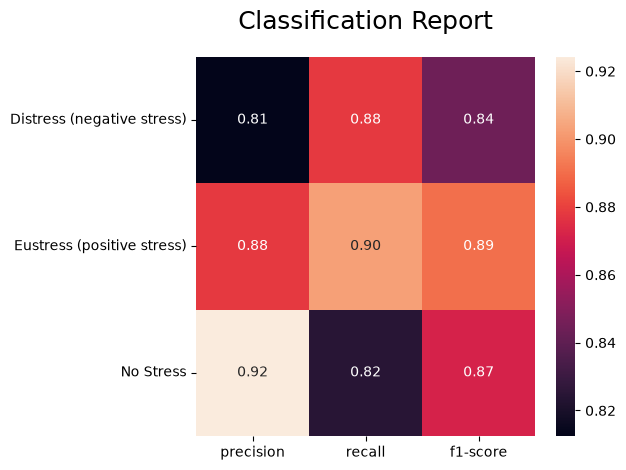

In [31]:
cr = classification_report(y_test, y_pred, output_dict = True, zero_division = 0, 
                          target_names =encoder.categories_[0])
cr_df = pd.DataFrame(cr).transpose()

heatmap = cr_df.iloc[: -3,  : ].drop(['support'], axis = 1)
sns.heatmap(heatmap, annot = True, fmt = '.2f')
plt.title('Classification Report', pad = 20, fontsize = 18)
plt.tight_layout()
plt.show()

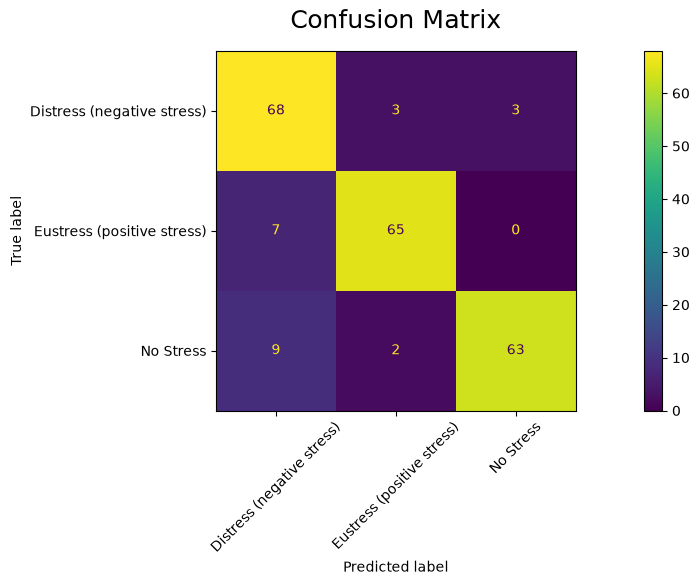

In [32]:
cm = confusion_matrix(y_test, vc_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = encoder.categories_[0])
fig, ax = plt.subplots()
fig.set_size_inches(14, 6)
disp.plot(ax = ax)
ax.set_title("Confusion Matrix", y = 1.04, fontsize = 18)
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.setp(ax.get_xticklabels(), rotation = 45)
plt.tight_layout()
plt.show()


In [33]:
np.random.seed(42)  # reproducibility

n_samples = 5  # only 5 rows

data = {
    "anxiety_level": np.random.randint(1, 22, n_samples),       
    "self_esteem": np.random.randint(2, 31, n_samples),         # 2–30
    "depression": np.random.randint(1, 26, n_samples),          # 1–21
    "blood_pressure": np.random.randint(1, 6, n_samples),       # 1–5
    "sleep_quality": np.random.randint(1, 6, n_samples),        # 1–5
    "breathing_problem": np.random.randint(1, 6, n_samples),    # 1–5
    "noise_level": np.random.randint(1, 6, n_samples),          # 1–5
    "basic_needs": np.random.randint(1, 6, n_samples),          # 1–5
    "study_load": np.random.randint(1, 6, n_samples),           # 1–5
    "bullying": np.random.randint(1, 6, n_samples)              # 1–5
}

data_df = pd.DataFrame(data)
data_df.head(2)


,anxiety_level,self_esteem,depression,blood_pressure,sleep_quality,breathing_problem,noise_level,basic_needs,study_load,bullying
0,7,30,23,4,2,2,3,3,5,4
1,20,22,11,3,4,5,3,4,3,1


In [34]:
for col in data_df.columns:
        data_df[col] = ss.fit_transform(data_df[[col]])

In [35]:
prediction = vc_model.predict(data_df)
print(prediction)

[1 1 1 1 0]


In [36]:
stress_level = encoder.inverse_transform(prediction.reshape(-1, 1))
print(f'Stress level {stress_level.ravel()}')

Stress level ['Eustress (positive stress)' 'Eustress (positive stress)'
 'Eustress (positive stress)' 'Eustress (positive stress)'
 'Distress (negative stress)']
